# Plot: S27 Method Comparison Case Study


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

PAPER_RC = {
    # Font sizes
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 9,
    "figure.titlesize": 12,

    # Figure settings
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "figure.figsize": (6.5, 3.5),

    # Style
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "axes.axisbelow": True,

    # Font family
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
}

def apply_paper_style():
    """Apply paper-ready matplotlib style."""
    plt.rcParams.update(PAPER_RC)

apply_paper_style()


In [2]:
# =========================
# 1) 路径与配置
# =========================
# 默认从 notebooks/26Feb2-mcm 目录运行
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
DATA_DIR = os.path.join(BASE_DIR, "data", "26Feb2-mcm")
FIGDIR = os.path.join(BASE_DIR, "figures", "26Feb2-mcm", "11_s27_method_comparison")

# LaTeX single-column figure sizes
FIGSIZE_STANDARD = (6.5, 3.5)
FIGSIZE_WIDE = (6.5, 2.8)
FIGSIZE_TALL = (6.5, 4.5)
FIGSIZE_DUAL = (8.6, 3.2)
DPI = 300

FIGSIZE = FIGSIZE_TALL

SEASON = 27
MAX_WEEK = 11

DATA_CSV = os.path.join(DATA_DIR, "task2", "method_compare_by_week.csv")
OUT_PDF = os.path.join(FIGDIR, "s27_method_comparison.pdf")

os.makedirs(FIGDIR, exist_ok=True)


In [3]:
# -------------------------
# utils
# -------------------------

def pick_col(df: pd.DataFrame, candidates: list[str], required: bool = True) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise ValueError(f"找不到列（候选：{candidates}），实际列名：{list(df.columns)}")
    return None


# -------------------------
# plotting
# -------------------------

def plot_s27_method_comparison(data_path: str, output_path: str, season: int = SEASON, max_week: int = MAX_WEEK):
    """Generate S27 method comparison plot."""
    by_week = pd.read_csv(data_path, encoding="utf-8-sig")

    season_col = pick_col(by_week, ["season", "Season"])
    week_col = pick_col(by_week, ["week", "Week"])
    pct_col = pick_col(by_week, ["pct_match", "pct", "percentage_match"], required=True)
    rank_col = pick_col(by_week, ["rank_match", "rank", "rank_match_rate"], required=True)

    by_week[season_col] = pd.to_numeric(by_week[season_col], errors="coerce").astype("Int64")
    by_week[week_col] = pd.to_numeric(by_week[week_col], errors="coerce").astype("Int64")

    s27 = by_week[(by_week[season_col] == season) & (by_week[week_col] >= 1) & (by_week[week_col] <= max_week)].copy()

    fig, ax = plt.subplots(figsize=FIGSIZE)

    weeks = s27[week_col].to_numpy()
    pct_match = s27[pct_col].to_numpy()
    rank_match = s27[rank_col].to_numpy()

    x = np.arange(len(weeks))
    width = 0.35

    ax.bar(x - width/2, pct_match, width, label="Percentage", color="#4C78A8", alpha=0.8)
    ax.bar(x + width/2, rank_match, width, label="Rank", color="#F58518", alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels([f"W{w}" for w in weeks])
    ax.set_xlabel("Week")
    ax.set_ylabel("Match with Actual (0/1)")
    fig.suptitle("Season 27: Method Accuracy Comparison", x=0.48, y=0.97, ha="center", fontsize=12, fontweight="bold")
    ax.legend()
    ax.set_ylim(0, 1.1)

    plt.tight_layout()
    plt.savefig(output_path, dpi=DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_path}")


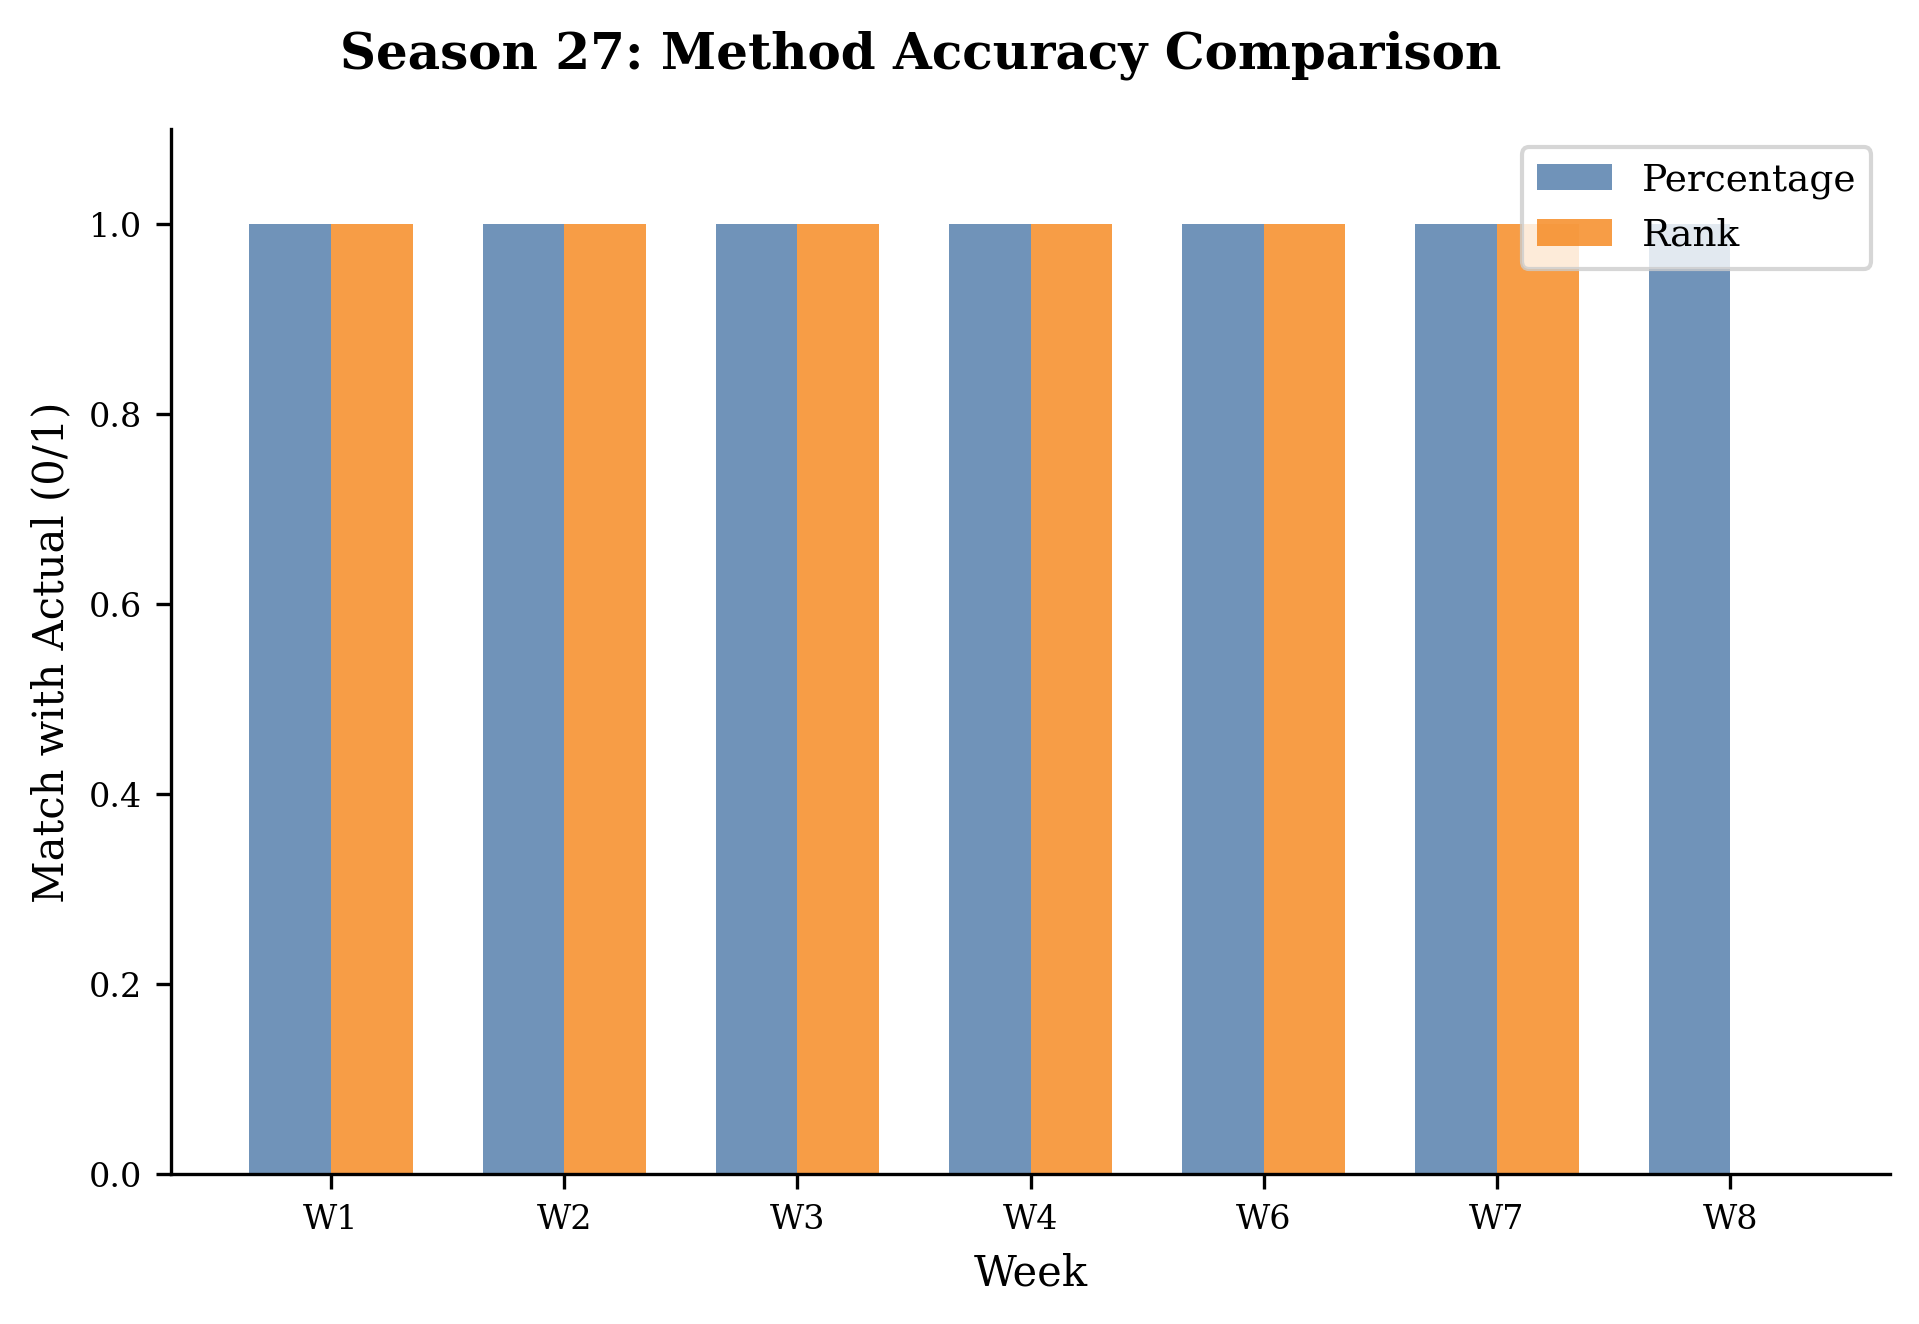

Saved: /home/winbeau/Tools/jupyter-plot/figures/26Feb2-mcm/11_s27_method_comparison/s27_method_comparison.pdf
Saved: /home/winbeau/Tools/jupyter-plot/figures/26Feb2-mcm/11_s27_method_comparison/s27_method_comparison.pdf


In [4]:
plot_s27_method_comparison(DATA_CSV, OUT_PDF)
print("Saved:", OUT_PDF)
